# Erken Durdurma (Early Stopping)

## Temel Kavram

Erken durdurma, yinelemeli (iterative) öğrenme algoritmalarında (Gradyan İnişi gibi) aşırı öğrenmeyi (overfitting) engellemek için kullanılan bir **regülarizasyon** yöntemidir.

Mantığı oldukça basittir:
1. Eğitim sırasında modelin performansı hem eğitim setinde hem de doğrulama (validation) setinde izlenir.
2. Eğitim hatası genellikle sürekli azalırken, doğrulama hatası bir noktadan sonra artmaya başlar.
3. Doğrulama hatasının en düşük olduğu (minimum) noktada eğitimi durdururuz.

---

## Neden Regülarizasyon Sayılır?

Lasso (L1) ve Ridge (L2) katsayıları doğrudan matematiksel bir ceza terimi ile sınırlar. Erken durdurma ise **öğrenme süresini** sınırlayarak katsayıların aşırı büyümesine ve karmaşıklaşmasına izin vermez.

Geometrik olarak, ağırlıklar (weights) başlangıç noktalarından (genellikle sıfıra yakın) çok uzağa gitmeden durdurulduğu için katsayıların normu küçük kalır.

---

## Algoritma Akışı

1. Veriyi Eğitim ve Doğrulama olarak ayır.
2. Her yinelemede (epoch):
   - Modeli eğitim verisiyle güncelle.
   - Doğrulama hatasını hesapla.
   - Eğer doğrulama hatası $n$ adım boyunca iyileşmiyorsa: **DUR** ve en iyi ağırlıklara geri dön.

## Görselleştirme

<div style="display: flex; justify-content: center;">
  <img src="../figures/early-stopping.png" width="60%">
</div>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

# 1. Sentetik Veri Oluşturma
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X + 0.5 * X**2 + np.random.randn(m, 1)

X_train, X_val, y_train, y_val = train_test_split(X, y.ravel(), test_size=0.2, random_state=10)

# 2. Veri Hazırlama (Polinom Özellikleri + Ölçeklendirme)
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler())
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

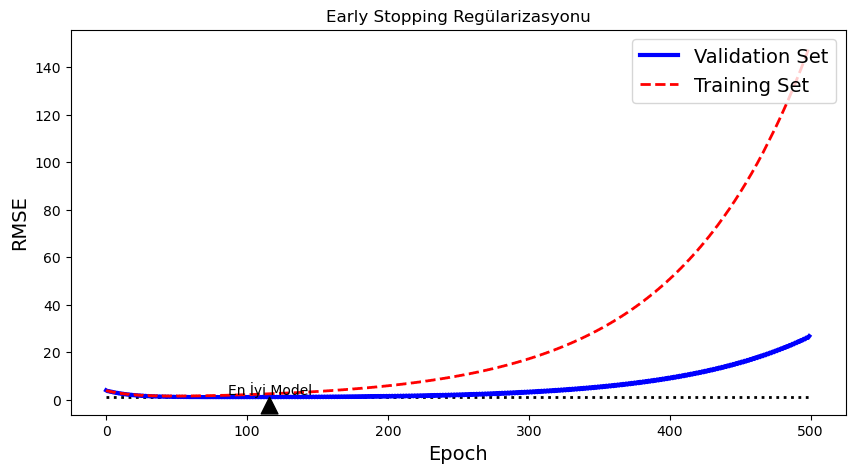

In [3]:
# 3. Manuel Erken Durdurma Simülasyonu
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True, 
                       penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

n_epochs = 500
train_errors, val_errors = [], []

for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

best_epoch = np.argmin(val_errors)
best_val_rmse = np.sqrt(val_errors[best_epoch])

# 4. Sonuçları Görselleştirme
plt.figure(figsize=(10, 5))
plt.annotate('En İyi Model', 
             xy=(best_epoch, best_val_rmse), 
             xytext=(best_epoch, best_val_rmse + 1), 
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.plot([0, n_epochs], [best_val_rmse, best_val_rmse], "k:", linewidth=2)
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation Set")
plt.plot(np.sqrt(train_errors), "r--", linewidth=2, label="Training Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.title("Early Stopping Regülarizasyonu")
plt.show()

## Karşılaştırma Özeti

| Yöntem | Yaklaşım | Temel Avantaj |
|---|---|---|
| **Ridge (L2)** | Ağırlıkların karesini cezalandırır | Katsayıları küçültür, aşırı duyarlılığı azaltır |
| **Lasso (L1)** | Ağırlıkların mutlak değerini cezalandırır | Gereksiz özellikleri tamamen sıfırlar (Feature Selection) |
| **Early Stopping** | Eğitimi zamanında durdurur | Hesaplama maliyeti yoktur, aşırı öğrenmeyi doğal yolla önler |